# Dataset Characteristics — English Train Split

Full profile of `datasets/english/train_labeled.csv`, the English
labelled training split used for Swift's ticket triage models.

Every ticket carries three independent labels:

| Column | Role | Type |
|---|---|---|
| `text` | The customer's ticket message | free text |
| `category` | What the ticket is about | multi-class, fine-grained |
| `sentiment` | Customer tone | 3-class ordinal (Negative/Neutral/Positive) — v5 labeling currently produces only Negative/Neutral in this split, see §4 |
| `priority` | Triage urgency | 3-class ordinal |

The notebook answers, in order: what is in the file, is it clean, how long is
the text, how is each label distributed, how do the labels relate to each
other, what vocabulary separates the classes, and how the split compares to
the test set. The final section collects the findings that change modelling
decisions.

In [ ]:
import re
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"

DATA_DIR = Path("../datasets/english")
TRAIN_PATH = DATA_DIR / "train_labeled.csv"
TEST_PATH = DATA_DIR / "test_labeled.csv"

# Fixed ordinal order — these labels are ranked, not nominal, so every table
# and chart in this notebook uses the same order rather than alphabetical.
PRIORITY_ORDER = ["Low", "Medium", "High"]
SENTIMENT_ORDER = ["Negative", "Neutral", "Positive"]

PRIORITY_COLORS = {"Low": "#7FB3D5", "Medium": "#F4B266", "High": "#D9534F"}
SENTIMENT_COLORS = {"Negative": "#D9534F", "Neutral": "#9AA5B1", "Positive": "#5CB85C"}

In [2]:
df = pd.read_csv(TRAIN_PATH)

print(f"File     : {TRAIN_PATH}")
print(f"Rows     : {len(df):,}")
print(f"Columns  : {list(df.columns)}")
print(f"Memory   : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head(10)

File     : ../datasets/llm-zeroshot/english/train_labeled.csv
Rows     : 10,003
Columns  : ['text', 'category', 'sentiment', 'priority']
Memory   : 2.9 MB


,text,category,sentiment,priority
0,I am still waiting on my card?,card_arrival,Neutral,Low
1,What can I do if my card still hasn't arrived after 2 weeks?,card_arrival,Neutral,Low
2,I have been waiting over a week. Is the card still coming?,card_arrival,Neutral,Low
3,Can I track my card while it is in the process of delivery?,card_arrival,Neutral,Low
4,"How do I know if I will get my card, or if it is lost?",card_arrival,Neutral,Low
5,When did you send me my new card?,card_arrival,Neutral,Low
6,Do you have info about the card on delivery?,card_arrival,Neutral,Low
7,What do I do if I still have not received my new card?,card_arrival,Neutral,Low
8,Does the package with my card have tracking?,card_arrival,Neutral,Low
9,I ordered my card but it still isn't here,card_arrival,Neutral,Low


## 1. Schema and integrity

Before any distribution is trustworthy, the file has to be clean: correct
types, no missing values, no duplicate tickets inflating a class, no stray
label spellings that would silently split a class in two.

In [3]:
schema = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "nulls": df.isna().sum(),
        "null_%": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(),
        "example": [df[c].iloc[0] for c in df.columns],
    }
)
schema

,dtype,non_null,nulls,null_%,unique,example
text,str,10003,0,0.0,10001,I am still waiting on my card?
category,str,10003,0,0.0,77,card_arrival
sentiment,str,10003,0,0.0,2,Neutral
priority,str,10003,0,0.0,3,Low


### Duplicates

Two kinds matter. A **full-row duplicate** is a harmless repeat. A **text
duplicate with conflicting labels** is a genuine annotation conflict and
would teach the model contradictory targets.

In [4]:
full_dupes = df.duplicated().sum()
text_dupes = df["text"].duplicated().sum()

conflicts = (
    df.groupby("text")[["category", "priority", "sentiment"]]
    .nunique()
    .query("category > 1 or priority > 1 or sentiment > 1")
)

print(f"Full-row duplicates          : {full_dupes}")
print(f"Duplicate text values        : {text_dupes}")
print(f"Texts with conflicting labels: {len(conflicts)}")

if text_dupes:
    repeated = df[df["text"].duplicated(keep=False)].sort_values("text")
    print("\nRepeated texts:")
    display(repeated)

Full-row duplicates          : 2
Duplicate text values        : 2
Texts with conflicting labels: 0

Repeated texts:


,text,category,sentiment,priority
1246,I can't seem to be able to use my card,card_not_working,Neutral,Medium
1290,I can't seem to be able to use my card,card_not_working,Neutral,Medium
608,Why have I been charged an extra Rs 10?,extra_charge_on_statement,Neutral,Medium
627,Why have I been charged an extra Rs 10?,extra_charge_on_statement,Neutral,Medium


### Label hygiene

Checks for whitespace padding, casing variants, and any label value outside
the expected vocabulary — the failure mode where `"High"` and `"high "`
become two separate classes.

In [5]:
for col in ["category", "sentiment", "priority"]:
    values = df[col].astype(str)
    padded = (values != values.str.strip()).sum()
    case_collisions = values.str.lower().nunique() != values.nunique()
    print(f"{col:10s} | {values.nunique():3d} unique | padded: {padded} | case collisions: {case_collisions}")

print(f"\nUnexpected priority values : {sorted(set(df['priority']) - set(PRIORITY_ORDER))}")
print(f"Unexpected sentiment values: {sorted(set(df['sentiment']) - set(SENTIMENT_ORDER))}")

# Empty or whitespace-only tickets would pass a null check but carry no signal.
blank_text = df["text"].astype(str).str.strip().eq("").sum()
print(f"Blank/whitespace-only texts: {blank_text}")

category   |  77 unique | padded: 0 | case collisions: False
sentiment  |   2 unique | padded: 0 | case collisions: False
priority   |   3 unique | padded: 0 | case collisions: False

Unexpected priority values : []
Unexpected sentiment values: []
Blank/whitespace-only texts: 0


## 2. Text characteristics

Length drives the tokeniser budget and the max-sequence-length choice for the
transformer baselines, so it is measured in characters, words, and tokens.

In [6]:
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].str.split().str.len()

length_stats = df[["n_chars", "n_words"]].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).T.round(2)
length_stats

,count,mean,std,min,5%,25%,50%,75%,90%,95%,99%,max
n_chars,10003.0,59.54,40.91,13.0,26.0,36.0,47.0,64.0,109.0,152.0,221.98,433.0
n_words,10003.0,11.97,7.90,2.0,5.0,7.0,10.0,13.0,22.0,30.0,43.00,79.0


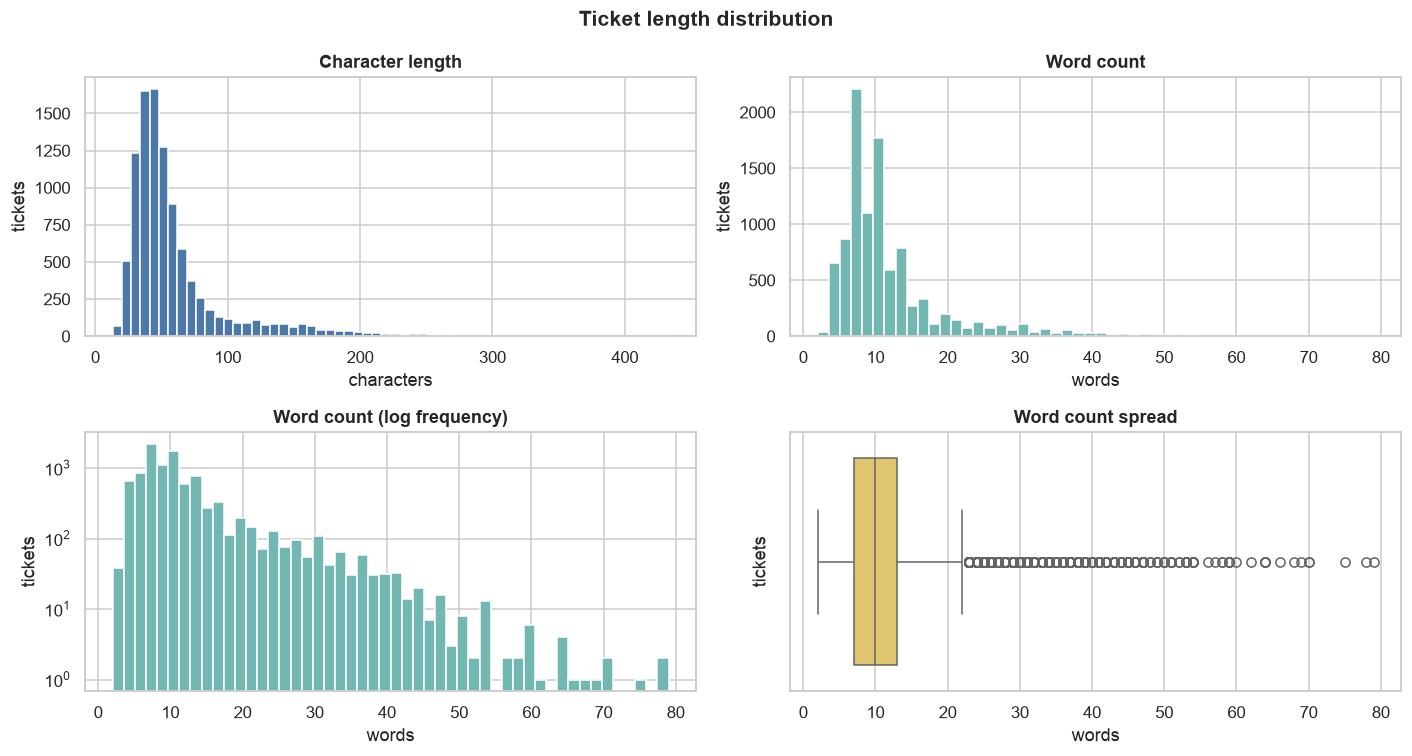

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

axes[0, 0].hist(df["n_chars"], bins=60, color="#4C78A8", edgecolor="white")
axes[0, 0].set_title("Character length")
axes[0, 0].set_xlabel("characters")

axes[0, 1].hist(df["n_words"], bins=50, color="#72B7B2", edgecolor="white")
axes[0, 1].set_title("Word count")
axes[0, 1].set_xlabel("words")

# Log scale exposes the right tail that the linear histogram flattens.
axes[1, 0].hist(df["n_words"], bins=50, color="#72B7B2", edgecolor="white")
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Word count (log frequency)")
axes[1, 0].set_xlabel("words")

sns.boxplot(x=df["n_words"], ax=axes[1, 1], color="#F2CF5B")
axes[1, 1].set_title("Word count spread")
axes[1, 1].set_xlabel("words")

for ax in axes.flat:
    ax.set_ylabel("tickets")

fig.suptitle("Ticket length distribution", fontsize=14, fontweight="bold")
plt.show()

In [8]:
p95, p99 = df["n_words"].quantile([0.95, 0.99])
print(f"95% of tickets are <= {p95:.0f} words")
print(f"99% of tickets are <= {p99:.0f} words")
print(f"Longest ticket           : {df['n_words'].max()} words / {df['n_chars'].max()} chars")
print(f"Shortest ticket          : {df['n_words'].min()} words / {df['n_chars'].min()} chars")

print("\nShortest tickets:")
display(df.nsmallest(5, "n_words")[["text", "category", "priority", "sentiment"]])

print("Longest tickets:")
display(df.nlargest(3, "n_words")[["text", "category", "priority", "sentiment"]])

95% of tickets are <= 30 words
99% of tickets are <= 43 words
Longest ticket           : 79 words / 433 chars
Shortest ticket          : 2 words / 13 chars

Shortest tickets:


,text,category,priority,sentiment
2187,Cancel Transaction,cancel_transfer,Medium,Neutral
4847,passcode retrieval,passcode_forgotten,Medium,Neutral
4889,Lost password,passcode_forgotten,Medium,Neutral
5176,pending transaction?,pending_card_payment,Low,Neutral
5561,Transfer declined.,declined_transfer,Medium,Neutral


Longest tickets:


,text,category,priority,sentiment
3917,Hearing back from us regarding your important verification results may take 10 minutes to one hour time. If verific...,unable_to_verify_identity,Low,Neutral
7310,Hi! I'm a university student studying abroad and I noticed that when I was trying to cross-reference my budget for t...,transfer_fee_charged,Medium,Neutral
3934,Hearing about your verification results from us may take anywhere from 10 minutes to approximately one hour. If thi...,unable_to_verify_identity,Low,Neutral


### Surface features

Cheap signals about how the tickets are written — these tell us whether the
text is conversational, whether numbers/entities appear often enough to be
worth extracting, and how much of the corpus is phrased as a question.

In [9]:
text = df["text"].astype(str)

surface = pd.Series(
    {
        "ends with '?'": text.str.strip().str.endswith("?").mean(),
        "contains a digit": text.str.contains(r"\d").mean(),
        "contains a currency symbol": text.str.contains(r"[$£€]|\brs\.?\b", case=False).mean(),
        "starts lowercase": text.str[0].str.islower().mean(),
        "contains uppercase word (3+)": text.str.contains(r"\b[A-Z]{3,}\b").mean(),
        "multi-sentence": text.str.count(r"[.!?]").ge(2).mean(),
    }
).mul(100).round(1)

surface.to_frame("% of tickets")

,% of tickets
ends with '?',59.5
contains a digit,2.5
contains a currency symbol,1.8
starts lowercase,5.3
contains uppercase word (3+),8.6
multi-sentence,17.5


### Vocabulary

Type-token ratio and coverage tell us how much lexical variety a model has to
generalise over, and how large a vocabulary a classical TF-IDF baseline needs.

In [10]:
tokens = text.str.lower().str.findall(r"[a-z']+").explode()
vocab = Counter(tokens.dropna())

total_tokens = sum(vocab.values())
print(f"Total tokens        : {total_tokens:,}")
print(f"Unique tokens       : {len(vocab):,}")
print(f"Type-token ratio    : {len(vocab) / total_tokens:.4f}")
print(f"Hapax legomena      : {sum(1 for c in vocab.values() if c == 1):,} "
      f"({sum(1 for c in vocab.values() if c == 1) / len(vocab) * 100:.1f}% of vocabulary)")

freqs = np.sort(np.array(list(vocab.values())))[::-1]
coverage = np.cumsum(freqs) / total_tokens
for target in (0.9, 0.95, 0.99):
    n = int(np.searchsorted(coverage, target) + 1)
    print(f"Top {n:>5,} words cover {target:.0%} of all tokens")

Total tokens        : 119,825
Unique tokens       : 2,354
Type-token ratio    : 0.0196
Hapax legomena      : 879 (37.3% of vocabulary)
Top   330 words cover 90% of all tokens
Top   544 words cover 95% of all tokens
Top 1,316 words cover 99% of all tokens


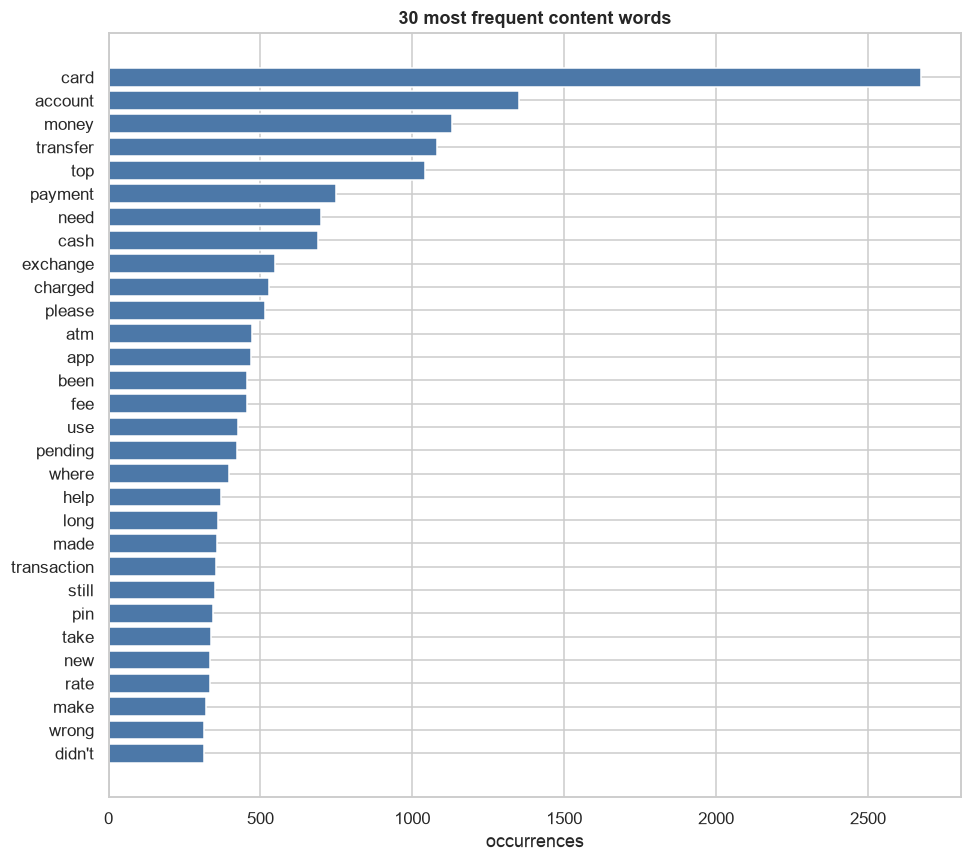

In [11]:
STOPWORDS = {
    "the", "a", "an", "i", "my", "me", "is", "it", "to", "of", "and", "in", "on",
    "for", "you", "your", "was", "do", "does", "did", "can", "how", "what", "why",
    "this", "that", "there", "be", "have", "has", "with", "at", "but", "not", "if",
    "am", "are", "were", "will", "would", "should", "could", "get", "got", "from",
    "when", "just", "so", "as", "by", "or", "no", "yes", "any", "all", "out", "up",
}

content_words = pd.Series({w: c for w, c in vocab.items() if w not in STOPWORDS and len(w) > 2})
top_words = content_words.sort_values(ascending=False).head(30)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top_words.index[::-1], top_words.values[::-1], color="#4C78A8")
ax.set_title("30 most frequent content words")
ax.set_xlabel("occurrences")
plt.show()

## 3. Category distribution

The primary classification target and the hardest of the three: many classes,
fine-grained, and unevenly filled.

In [12]:
cat_counts = df["category"].value_counts()

summary = pd.DataFrame(
    {
        "n": cat_counts,
        "%": (cat_counts / len(df) * 100).round(2),
        "cumulative_%": (cat_counts.cumsum() / len(df) * 100).round(2),
    }
)
summary.index.name = "category"

print(f"Number of categories : {df['category'].nunique()}")
print(f"Largest              : {cat_counts.index[0]} ({cat_counts.iloc[0]})")
print(f"Smallest             : {cat_counts.index[-1]} ({cat_counts.iloc[-1]})")
print(f"Imbalance ratio      : {cat_counts.iloc[0] / cat_counts.iloc[-1]:.1f}x")
print(f"Mean / median per class: {cat_counts.mean():.1f} / {cat_counts.median():.0f}")

summary

Number of categories : 77
Largest              : card_payment_fee_charged (187)
Smallest             : contactless_not_working (35)
Imbalance ratio      : 5.3x
Mean / median per class: 129.9 / 127


,n,%,cumulative_%
category,,,
card_payment_fee_charged,187,1.87,1.87
direct_debit_payment_not_recognised,182,1.82,3.69
balance_not_updated_after_cheque_or_cash_deposit,181,1.81,5.50
wrong_amount_of_cash_received,180,1.80,7.30
cash_withdrawal_charge,177,1.77,9.07
transaction_charged_twice,175,1.75,10.82
declined_cash_withdrawal,173,1.73,12.55
transfer_fee_charged,172,1.72,14.27
transfer_not_received_by_recipient,171,1.71,15.98


### Full category ranking

All classes on one axis, ordered by frequency. Reference lines mark the mean
class size and the 50-sample threshold below which a class is too thin to
learn reliably.

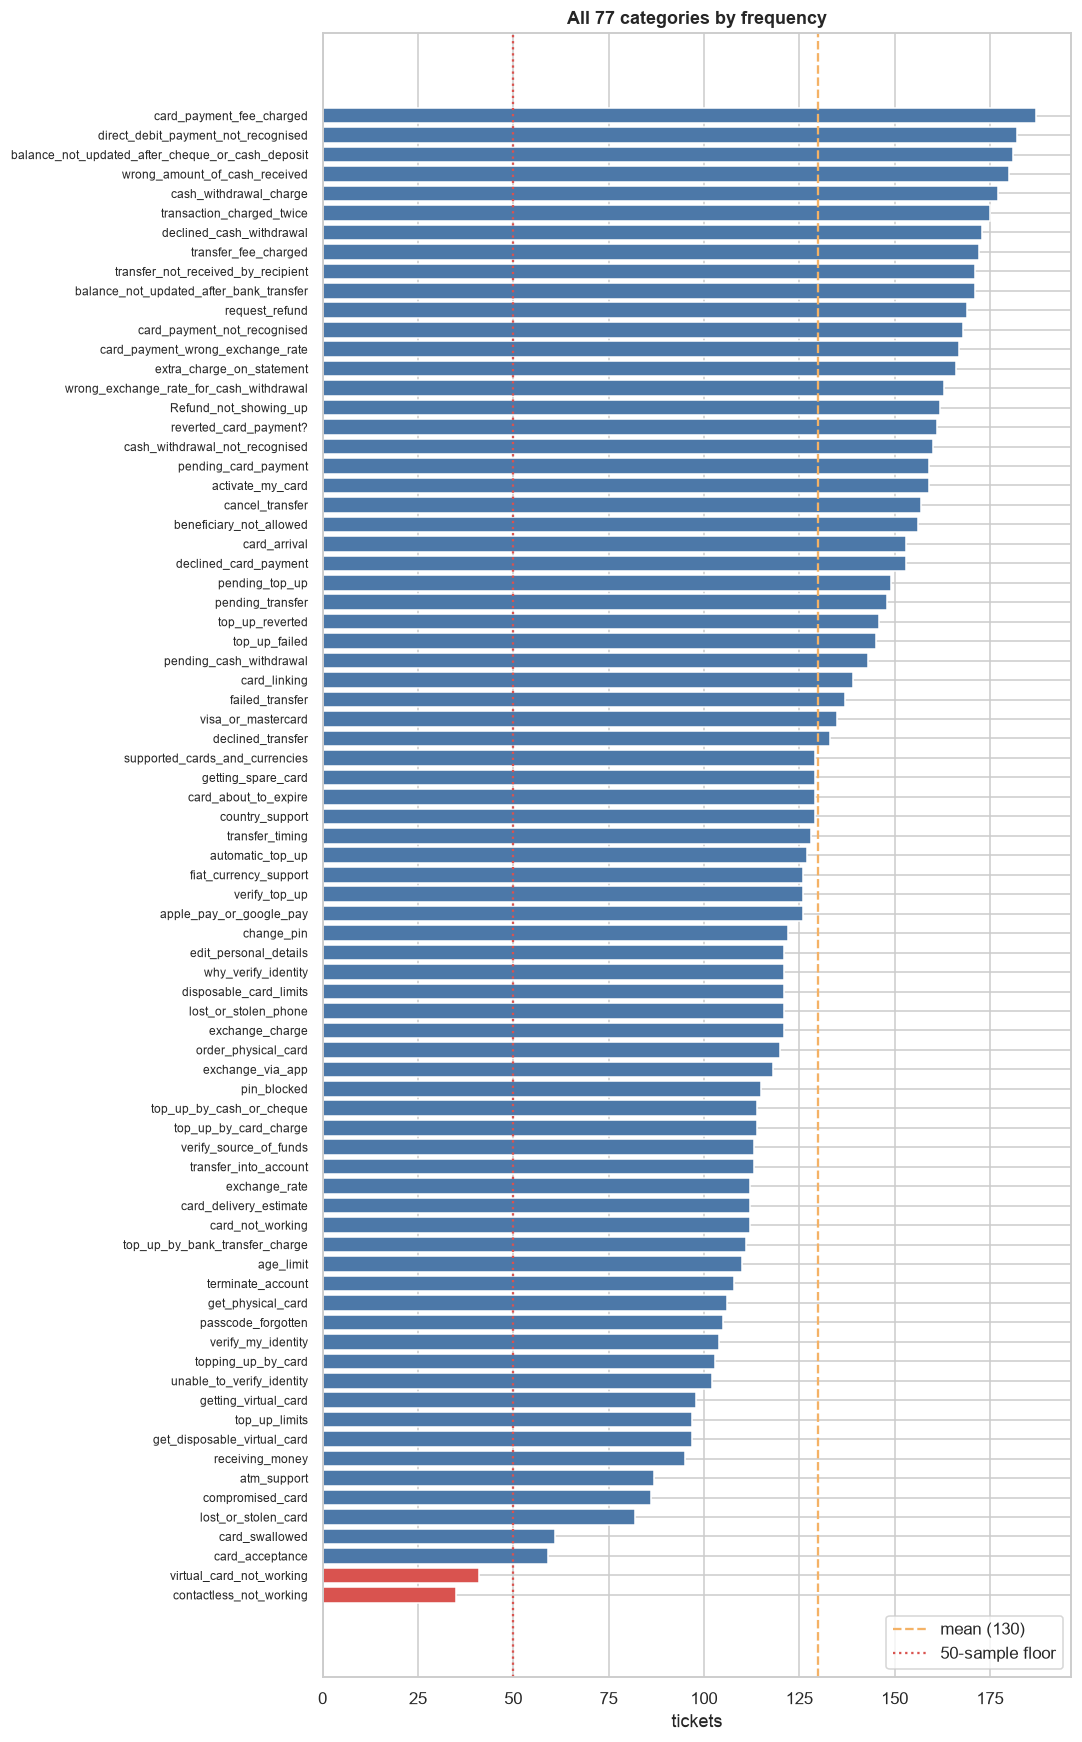

In [13]:
fig, ax = plt.subplots(figsize=(10, 16))
colors = ["#D9534F" if v < 50 else "#4C78A8" for v in cat_counts.values[::-1]]
ax.barh(cat_counts.index[::-1], cat_counts.values[::-1], color=colors)
ax.axvline(cat_counts.mean(), color="#F4B266", linestyle="--", label=f"mean ({cat_counts.mean():.0f})")
ax.axvline(50, color="#D9534F", linestyle=":", label="50-sample floor")
ax.set_title(f"All {df['category'].nunique()} categories by frequency")
ax.set_xlabel("tickets")
ax.legend(loc="lower right")
ax.tick_params(axis="y", labelsize=8)
plt.show()

### Concentration

How much of the corpus the top classes absorb. A steep curve means a
majority-class-biased model can score well while failing the tail entirely.

Gini impurity      : 0.9862
Shannon entropy    : 6.217 bits (max 6.267)
Normalised entropy : 0.9920  (1.0 = perfectly balanced)


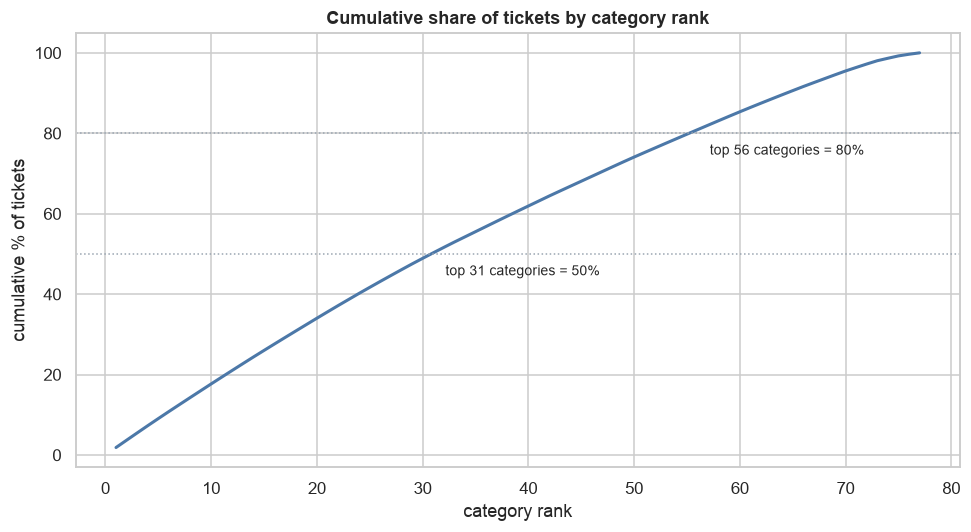

In [14]:
shares = (cat_counts / len(df)).values
gini = 1 - np.sum(shares ** 2)
entropy = -np.sum(shares * np.log2(shares))
max_entropy = np.log2(len(shares))

print(f"Gini impurity      : {gini:.4f}")
print(f"Shannon entropy    : {entropy:.3f} bits (max {max_entropy:.3f})")
print(f"Normalised entropy : {entropy / max_entropy:.4f}  (1.0 = perfectly balanced)")

fig, ax = plt.subplots(figsize=(9, 5))
cum = np.cumsum(shares) * 100
ax.plot(range(1, len(cum) + 1), cum, color="#4C78A8", linewidth=2)
for frac in (0.5, 0.8):
    n = int(np.searchsorted(cum / 100, frac) + 1)
    ax.axhline(frac * 100, color="#9AA5B1", linestyle=":", linewidth=1)
    ax.annotate(f"top {n} categories = {frac:.0%}", (n, frac * 100),
                textcoords="offset points", xytext=(8, -14), fontsize=9)
ax.set_title("Cumulative share of tickets by category rank")
ax.set_xlabel("category rank")
ax.set_ylabel("cumulative % of tickets")
plt.show()

In [15]:
thin = cat_counts[cat_counts < 50]
print(f"Categories under 50 samples: {len(thin)}")
if len(thin):
    display(thin.to_frame("n"))

# A 5-fold stratified split needs at least 5 examples per class per fold.
print(f"Categories under 5 samples (breaks stratified CV): {(cat_counts < 5).sum()}")

Categories under 50 samples: 2


,n
category,
virtual_card_not_working,41
contactless_not_working,35


Categories under 5 samples (breaks stratified CV): 0


### Category themes

The category names are structured (`card_arrival`, `card_payment_fee_charged`),
so the leading token gives a coarse topic grouping — useful for a
hierarchical or two-stage classifier.

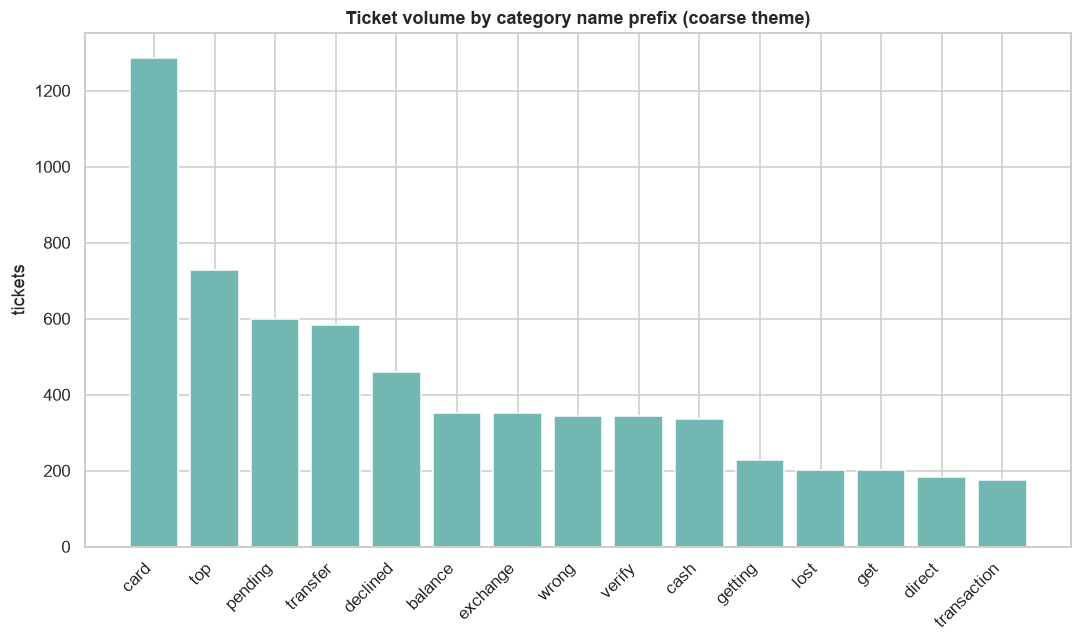

,tickets
category,
card,1287
top,727
pending,599
transfer,584
declined,459
balance,352
exchange,351
wrong,343
verify,343


In [16]:
themes = df["category"].str.split("_").str[0].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
top_themes = themes.head(15)
ax.bar(top_themes.index, top_themes.values, color="#72B7B2")
ax.set_title("Ticket volume by category name prefix (coarse theme)")
ax.set_ylabel("tickets")
ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")
plt.show()

top_themes.to_frame("tickets")

## 4. Sentiment distribution

Labelled by the v5 prompt (`datasets/translation/prompts/labeling_prompt_v5.md`),
not the original dataset's VADER heuristic. One change matters here: v5 never
assigns `Positive` in this training split — every ticket comes out either
`Neutral` or `Negative`. That is a genuine annotation finding, not a bug: a
human-annotated 500-row gold set (used to score v5) agrees, also showing 0
`Positive` tickets. Customers writing into a support channel essentially never
do so to express positive sentiment; `Positive` is kept in the ordinal order
below for structural consistency, and shows up as 0 throughout.

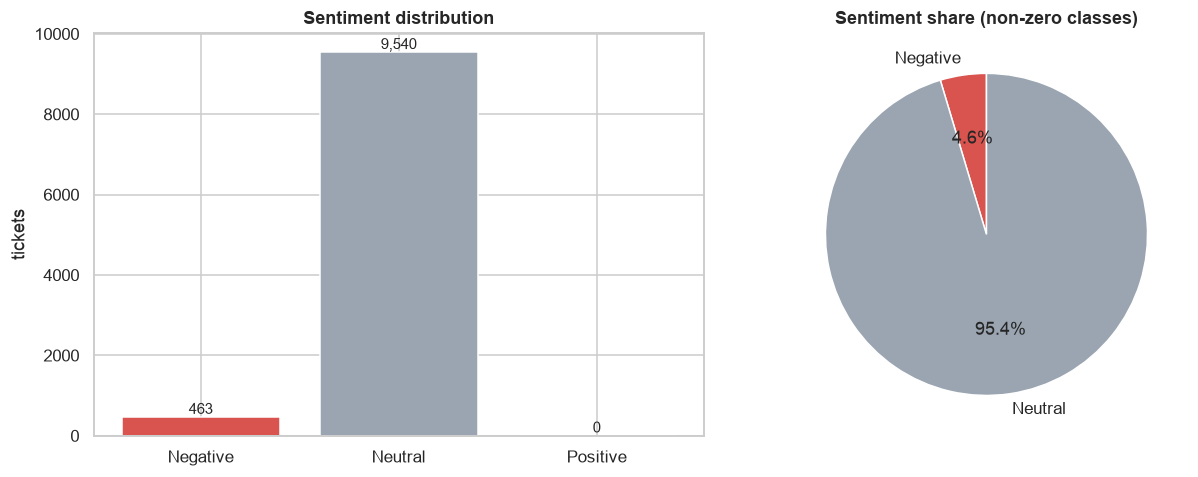

Classes with zero tickets under v5: ['Positive']
Imbalance ratio (majority : minority, non-zero classes) = 20.6x


,n,%
sentiment,,
Negative,463,4.63
Neutral,9540,95.37
Positive,0,0.00


In [17]:
sent_counts = df["sentiment"].value_counts().reindex(SENTIMENT_ORDER).fillna(0).astype(int)
sent_table = pd.DataFrame({"n": sent_counts, "%": (sent_counts / len(df) * 100).round(2)})

present = sent_counts[sent_counts > 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(sent_counts.index, sent_counts.values,
            color=[SENTIMENT_COLORS[s] for s in sent_counts.index])
axes[0].set_title("Sentiment distribution")
axes[0].set_ylabel("tickets")
for i, v in enumerate(sent_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)

# Zero-count classes (Positive, under v5) can't be drawn as a pie wedge —
# plot only the classes that actually occur.
axes[1].pie(present.values, labels=present.index, autopct="%1.1f%%",
            colors=[SENTIMENT_COLORS[s] for s in present.index],
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Sentiment share (non-zero classes)")
plt.show()

missing = sent_counts[sent_counts == 0].index.tolist()
if missing:
    print(f"Classes with zero tickets under v5: {missing}")
print(f"Imbalance ratio (majority : minority, non-zero classes) = "
      f"{present.max() / present.min():.1f}x")
sent_table

## 5. Priority distribution

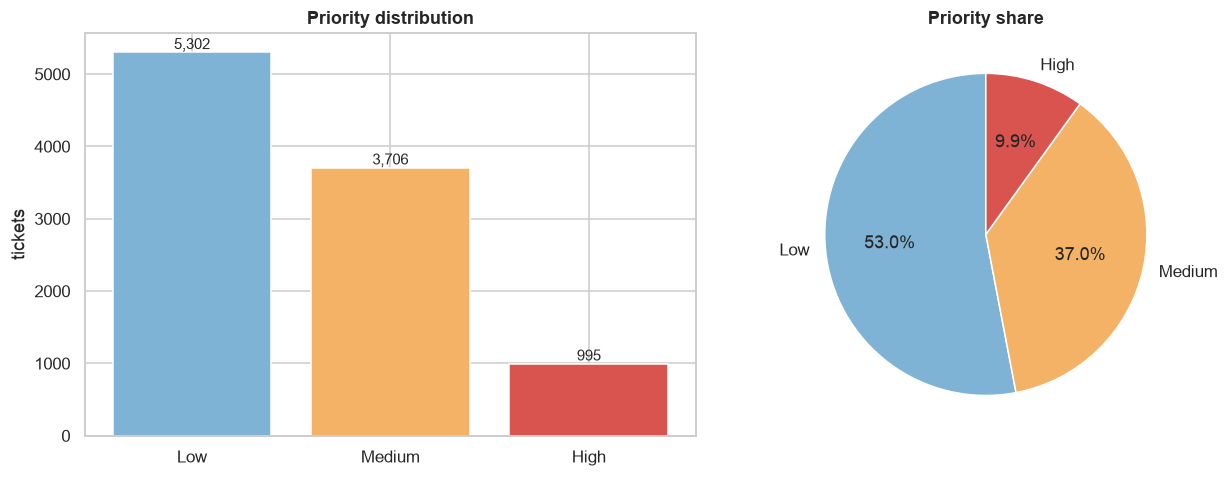

Imbalance ratio (majority : minority) = 5.3x


,n,%
priority,,
Low,5302,53.00
Medium,3706,37.05
High,995,9.95


In [18]:
prio_counts = df["priority"].value_counts().reindex(PRIORITY_ORDER)
prio_table = pd.DataFrame({"n": prio_counts, "%": (prio_counts / len(df) * 100).round(2)})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(prio_counts.index, prio_counts.values,
            color=[PRIORITY_COLORS[p] for p in prio_counts.index])
axes[0].set_title("Priority distribution")
axes[0].set_ylabel("tickets")
for i, v in enumerate(prio_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)

axes[1].pie(prio_counts.values, labels=prio_counts.index, autopct="%1.1f%%",
            colors=[PRIORITY_COLORS[p] for p in prio_counts.index],
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Priority share")
plt.show()

print(f"Imbalance ratio (majority : minority) = "
      f"{prio_counts.max() / prio_counts.min():.1f}x")
prio_table

## 6. How the labels relate to each other

The three targets are not independent. If `priority` is a deterministic
function of `category`, predicting it separately is redundant — a lookup on
the predicted category would do the same job. This section measures that.

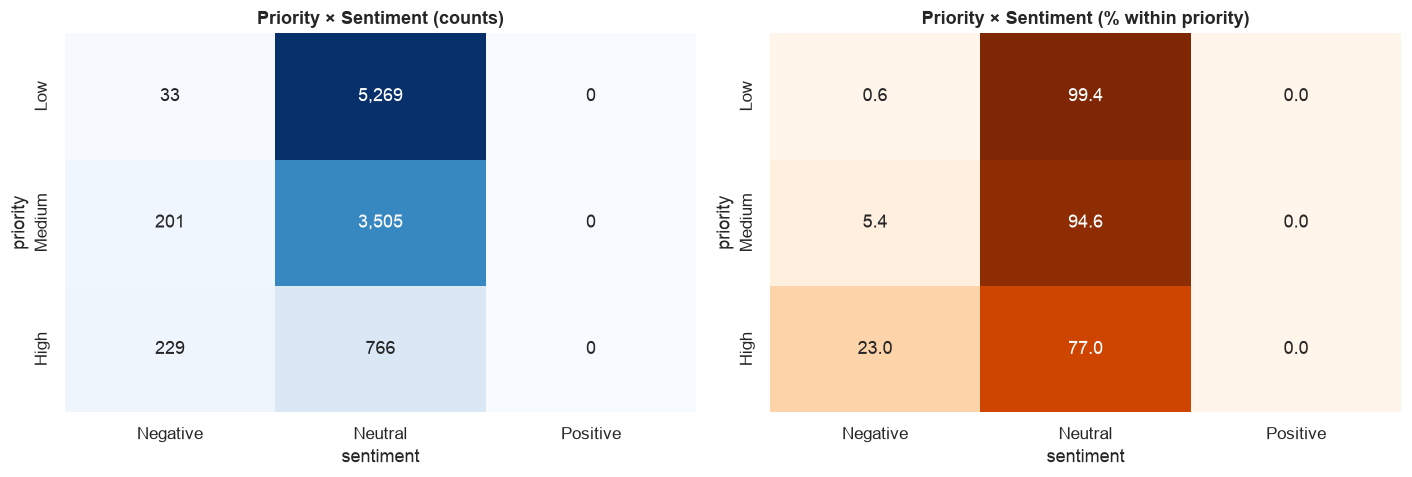

Cramér's V (priority vs sentiment): 0.310


In [19]:
ct = pd.crosstab(df["priority"], df["sentiment"]).reindex(
    index=PRIORITY_ORDER, columns=SENTIMENT_ORDER, fill_value=0
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(ct, annot=True, fmt=",d", cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title("Priority × Sentiment (counts)")

row_pct = ct.div(ct.sum(axis=1), axis=0) * 100
sns.heatmap(row_pct, annot=True, fmt=".1f", cmap="Oranges", ax=axes[1], cbar=False)
axes[1].set_title("Priority × Sentiment (% within priority)")
plt.show()

# Cramér's V — association strength between the two nominal labels, 0 to 1.
from scipy.stats import chi2_contingency

# Drop all-zero columns (e.g. Positive, absent under v5) — chi2_contingency
# rejects a table with an empty column.
ct_nonzero = ct.loc[:, ct.sum(axis=0) > 0]

chi2 = chi2_contingency(ct_nonzero)[0]
n = ct_nonzero.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct_nonzero.shape) - 1)))
print(f"Cramér's V (priority vs sentiment): {cramers_v:.3f}")

### Is priority determined by category?

In [20]:
prio_per_cat = df.groupby("category")["priority"].nunique()
sent_per_cat = df.groupby("category")["sentiment"].nunique()

n_cats = df["category"].nunique()
print(f"Categories mapping to exactly ONE priority : {(prio_per_cat == 1).sum()} / {n_cats}")
print(f"Categories mapping to exactly ONE sentiment: {(sent_per_cat == 1).sum()} / {n_cats}")

# Accuracy ceiling of the trivial rule "predict each category's most common priority".
majority_map = df.groupby("category")["priority"].agg(lambda s: s.mode()[0])
baseline_acc = (df["category"].map(majority_map) == df["priority"]).mean()
print(f"\nPriority accuracy from category alone (majority rule): {baseline_acc:.1%}")
print(f"Priority accuracy from always predicting 'Low'       : "
      f"{(df['priority'] == 'Low').mean():.1%}")

Categories mapping to exactly ONE priority : 22 / 77
Categories mapping to exactly ONE sentiment: 30 / 77

Priority accuracy from category alone (majority rule): 92.8%
Priority accuracy from always predicting 'Low'       : 53.0%


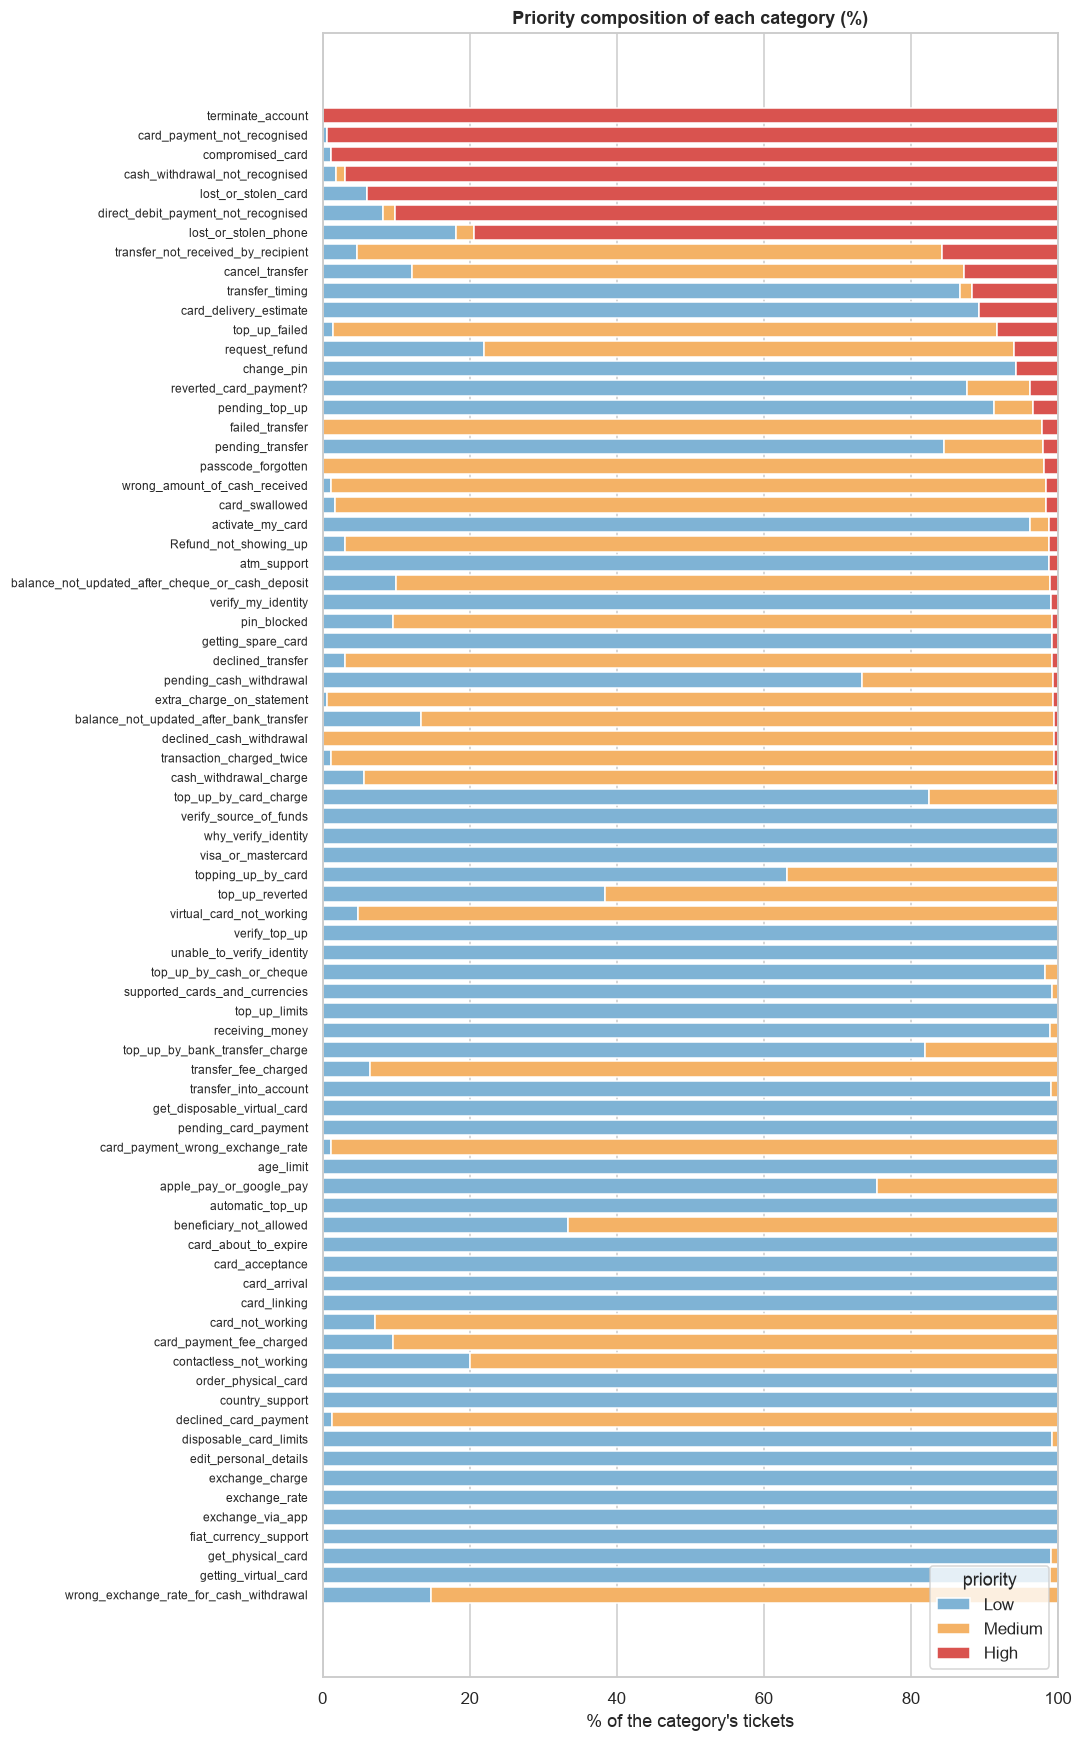

Categories that are entirely High priority:


['terminate_account']

In [21]:
# Where each category's priority mass sits — categories are ordered by how much
# High-priority traffic they carry, which is what escalation routing cares about.
cat_prio = pd.crosstab(df["category"], df["priority"]).reindex(columns=PRIORITY_ORDER, fill_value=0)
cat_prio_pct = cat_prio.div(cat_prio.sum(axis=1), axis=0) * 100
cat_prio_pct = cat_prio_pct.sort_values("High", ascending=False)

fig, ax = plt.subplots(figsize=(10, 16))
bottom = np.zeros(len(cat_prio_pct))
for p in PRIORITY_ORDER:
    ax.barh(cat_prio_pct.index, cat_prio_pct[p], left=bottom,
            color=PRIORITY_COLORS[p], label=p)
    bottom += cat_prio_pct[p].values
ax.set_title("Priority composition of each category (%)")
ax.set_xlabel("% of the category's tickets")
ax.set_xlim(0, 100)
ax.invert_yaxis()
ax.tick_params(axis="y", labelsize=8)
ax.legend(title="priority", loc="lower right")
plt.show()

print("Categories that are entirely High priority:")
display(cat_prio_pct[cat_prio_pct["High"] == 100].index.to_list())

In [22]:
print("Top 15 categories by share of Negative sentiment:")
cat_sent = pd.crosstab(df["category"], df["sentiment"]).reindex(columns=SENTIMENT_ORDER, fill_value=0)
cat_sent_pct = (cat_sent.div(cat_sent.sum(axis=1), axis=0) * 100).round(1)
cat_sent_pct.assign(n=cat_sent.sum(axis=1)).sort_values("Negative", ascending=False).head(15)

Top 15 categories by share of Negative sentiment:


sentiment,Negative,Neutral,Positive,n
category,,,,
card_payment_not_recognised,31.5,68.5,0.0,168
cash_withdrawal_not_recognised,28.1,71.9,0.0,160
direct_debit_payment_not_recognised,24.2,75.8,0.0,182
top_up_reverted,21.9,78.1,0.0,146
terminate_account,20.4,79.6,0.0,108
declined_card_payment,15.0,85.0,0.0,153
lost_or_stolen_card,14.6,85.4,0.0,82
compromised_card,14.0,86.0,0.0,86
transfer_fee_charged,9.3,90.7,0.0,172


## 7. Text length across labels

If length varies systematically by class, a model can partly cheat on length
alone — worth knowing before reading too much into a strong baseline.

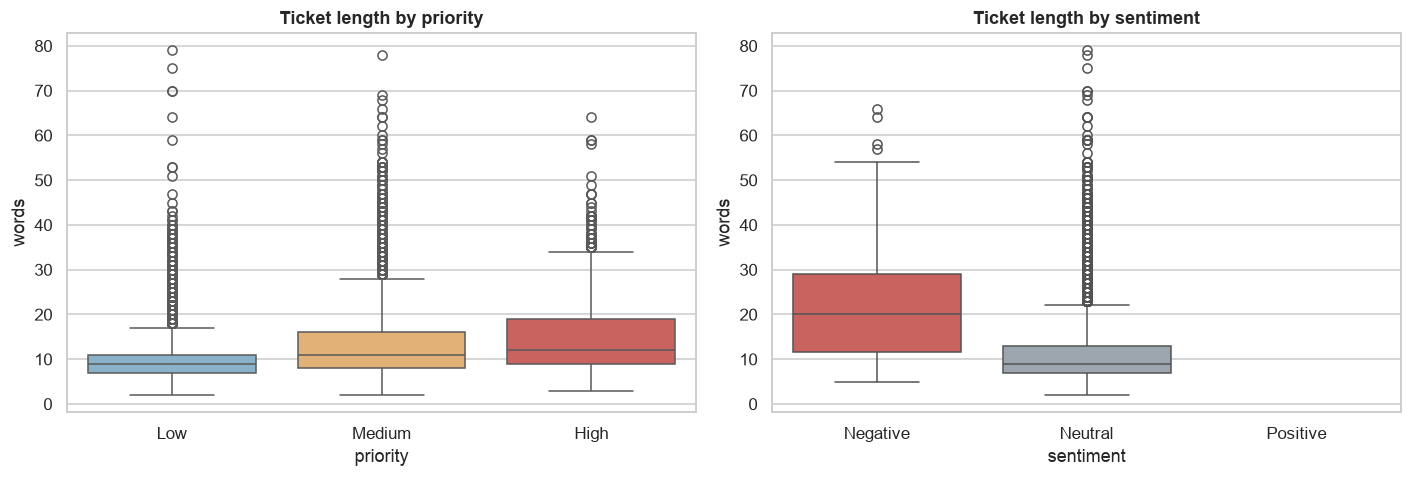

,count,mean,50%,max
priority,,,,
Low,5302.0,9.92,9.0,79.0
Medium,3706.0,14.08,11.0,78.0
High,995.0,14.99,12.0,64.0


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=df, x="priority", y="n_words", order=PRIORITY_ORDER,
            palette=PRIORITY_COLORS, ax=axes[0])
axes[0].set_title("Ticket length by priority")
axes[0].set_ylabel("words")

sns.boxplot(data=df, x="sentiment", y="n_words", order=SENTIMENT_ORDER,
            palette=SENTIMENT_COLORS, ax=axes[1])
axes[1].set_title("Ticket length by sentiment")
axes[1].set_ylabel("words")

plt.show()

df.groupby("priority")["n_words"].describe().reindex(PRIORITY_ORDER)[
    ["count", "mean", "50%", "max"]
].round(2)

## 8. Vocabulary that separates the classes

Log-odds ratio with an informative Dirichlet prior — for each class, the words
most over-represented relative to the rest of the corpus. Unlike raw
frequency this is not dominated by common words, so it shows what a model
would actually key on.

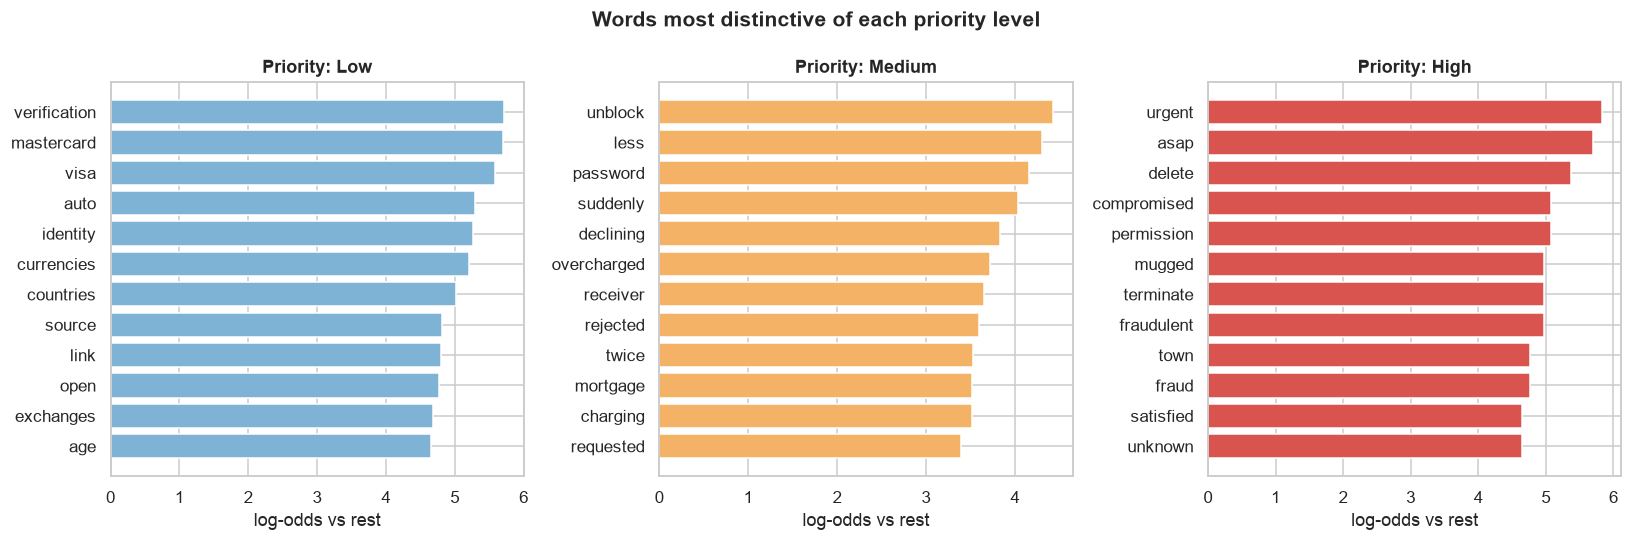

In [24]:
def distinctive_terms(frame: pd.DataFrame, label_col: str, label: str, top_n: int = 12) -> pd.Series:
    """Words most over-represented in `label` versus every other class."""
    in_class = Counter(
        w for t in frame.loc[frame[label_col] == label, "text"]
        for w in re.findall(r"[a-z']+", t.lower()) if w not in STOPWORDS and len(w) > 2
    )
    out_class = Counter(
        w for t in frame.loc[frame[label_col] != label, "text"]
        for w in re.findall(r"[a-z']+", t.lower()) if w not in STOPWORDS and len(w) > 2
    )
    n_in, n_out = sum(in_class.values()), sum(out_class.values())
    alpha = 0.5  # smoothing, so a single rare word cannot dominate the ranking

    scores = {
        w: np.log((in_class[w] + alpha) / (n_in + alpha)) - np.log((out_class[w] + alpha) / (n_out + alpha))
        for w in in_class
        if in_class[w] >= 5
    }
    return pd.Series(scores).sort_values(ascending=False).head(top_n)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, label in zip(axes, PRIORITY_ORDER):
    terms = distinctive_terms(df, "priority", label)
    ax.barh(terms.index[::-1], terms.values[::-1], color=PRIORITY_COLORS[label])
    ax.set_title(f"Priority: {label}")
    ax.set_xlabel("log-odds vs rest")
fig.suptitle("Words most distinctive of each priority level", fontsize=14, fontweight="bold")
plt.show()

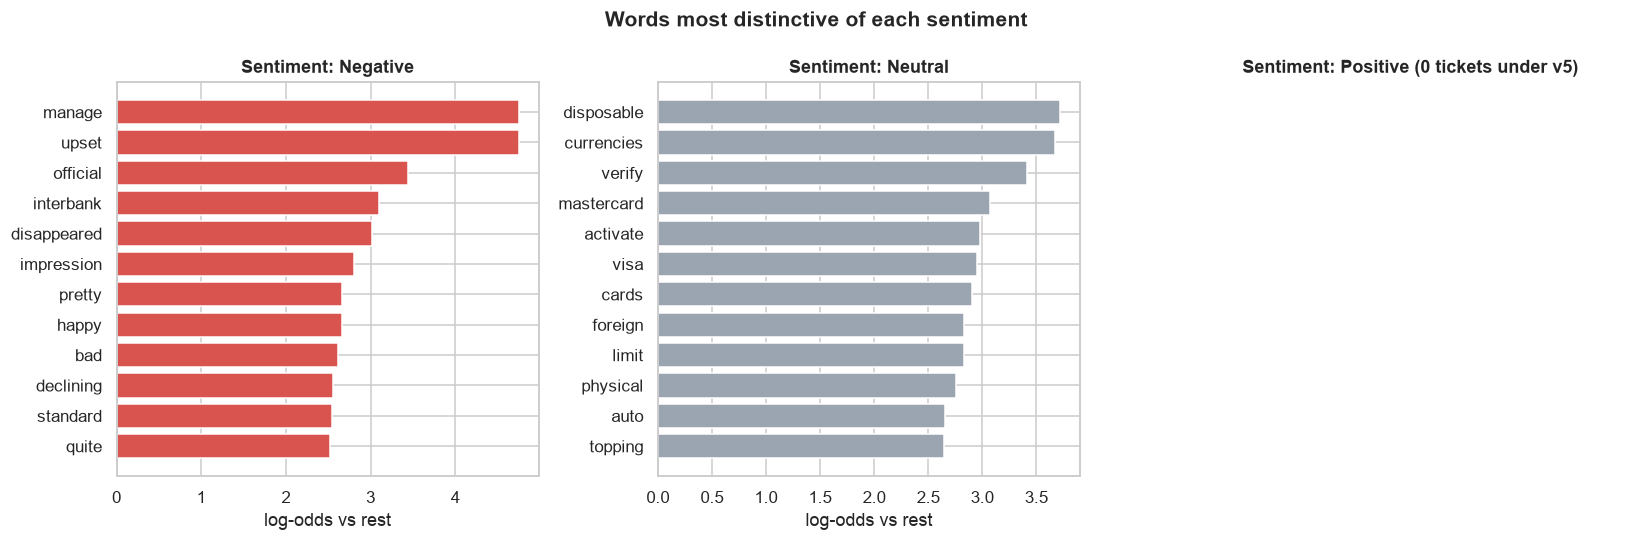

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, label in zip(axes, SENTIMENT_ORDER):
    if (df["sentiment"] == label).sum() == 0:
        ax.set_title(f"Sentiment: {label} (0 tickets under v5)")
        ax.axis("off")
        continue
    terms = distinctive_terms(df, "sentiment", label)
    ax.barh(terms.index[::-1], terms.values[::-1], color=SENTIMENT_COLORS[label])
    ax.set_title(f"Sentiment: {label}")
    ax.set_xlabel("log-odds vs rest")
fig.suptitle("Words most distinctive of each sentiment", fontsize=14, fontweight="bold")
plt.show()

## 9. Sample tickets by label

Numbers only go so far — reading actual rows is how annotation quirks get
caught.

In [26]:
for label in PRIORITY_ORDER:
    print(f"\n{'=' * 70}\nPRIORITY: {label}\n{'=' * 70}")
    sample = df[df["priority"] == label].sample(4, random_state=42)
    for _, row in sample.iterrows():
        print(f"  [{row['category']} | {row['sentiment']}]")
        print(f"    {row['text']}")


PRIORITY: Low
  [receiving_money | Neutral]
    What do I need to do to receive my payroll in the account?
  [top_up_by_cash_or_cheque | Neutral]
    Can I top up with cash
  [transfer_into_account | Neutral]
    How can I top up my account by bank transfer?
  [edit_personal_details | Neutral]
    I need to change my name, since i just got married

PRIORITY: Medium
  [wrong_exchange_rate_for_cash_withdrawal | Neutral]
    I noticed my exchange rate was incorrect when I got cash.
  [card_payment_fee_charged | Neutral]
    Why was I charged a fee for debit or credit card payment?
  [declined_transfer | Neutral]
    I saw that my transfer was declined.
  [wrong_amount_of_cash_received | Negative]
    I tried taking out Rs 30,000 from the ATM just now and it only gave me Rs 10,000. Why would it do that? I need the Rs 30,000 now!

PRIORITY: High
  [cash_withdrawal_not_recognised | Neutral]
    there is money in my account that i didnt put there
  [direct_debit_payment_not_recognised | Neut

In [27]:
for label in SENTIMENT_ORDER:
    print(f"\n{'=' * 70}\nSENTIMENT: {label}\n{'=' * 70}")
    subset = df[df["sentiment"] == label]
    if subset.empty:
        print(f"  (0 tickets — v5 assigns no '{label}' sentiment in this split)")
        continue
    sample = subset.sample(min(4, len(subset)), random_state=42)
    for _, row in sample.iterrows():
        print(f"  [{row['category']} | {row['priority']}]")
        print(f"    {row['text']}")


SENTIMENT: Negative
  [direct_debit_payment_not_recognised | High]
    I have an unauthorized direct debit on my account
  [lost_or_stolen_card | High]
    My card is stolen.  Help!
  [pending_top_up | High]
    Sort your top up out please! It's been pending since an hour already, can you please make this go through asap I really need the money
  [direct_debit_payment_not_recognised | High]
    Hi, i was checking my old statements and found a discrepancy with a large amount transaction. I am sure it was not done by me. Please let me know if i could raise a dispute as its very late.

SENTIMENT: Neutral
  [get_physical_card | Low]
    Tell me about the card PIN?
  [disposable_card_limits | Low]
    How many transactions can I make on my disposable card?
  [balance_not_updated_after_bank_transfer | Medium]
    Hello, can you please inform me about international transfers? I am expecting a transfer I made from France two days ago and would like to know when it will arrive.
  [age_limit | 

## 10. Train vs test comparison

Two questions: do the splits share the same label distribution (if not, test
scores will not reflect training conditions), and is there text leakage
between them (which would inflate every metric).

In [28]:
test_df = pd.read_csv(TEST_PATH)

print(f"Train rows : {len(df):,}")
print(f"Test rows  : {len(test_df):,}")
print(f"Test share : {len(test_df) / (len(df) + len(test_df)):.1%}")
print(f"Categories — train: {df['category'].nunique()}, test: {test_df['category'].nunique()}")

missing_in_test = set(df["category"]) - set(test_df["category"])
unseen_in_train = set(test_df["category"]) - set(df["category"])
print(f"Categories in train but not test: {sorted(missing_in_test) or 'none'}")
print(f"Categories in test but not train: {sorted(unseen_in_train) or 'none'}")

overlap = set(df["text"]) & set(test_df["text"])
print(f"\nExact text overlap between splits: {len(overlap)} "
      f"{'— LEAKAGE' if overlap else '— clean'}")

Train rows : 10,003
Test rows  : 3,080
Test share : 23.5%
Categories — train: 77, test: 77
Categories in train but not test: none
Categories in test but not train: none

Exact text overlap between splits: 0 — clean


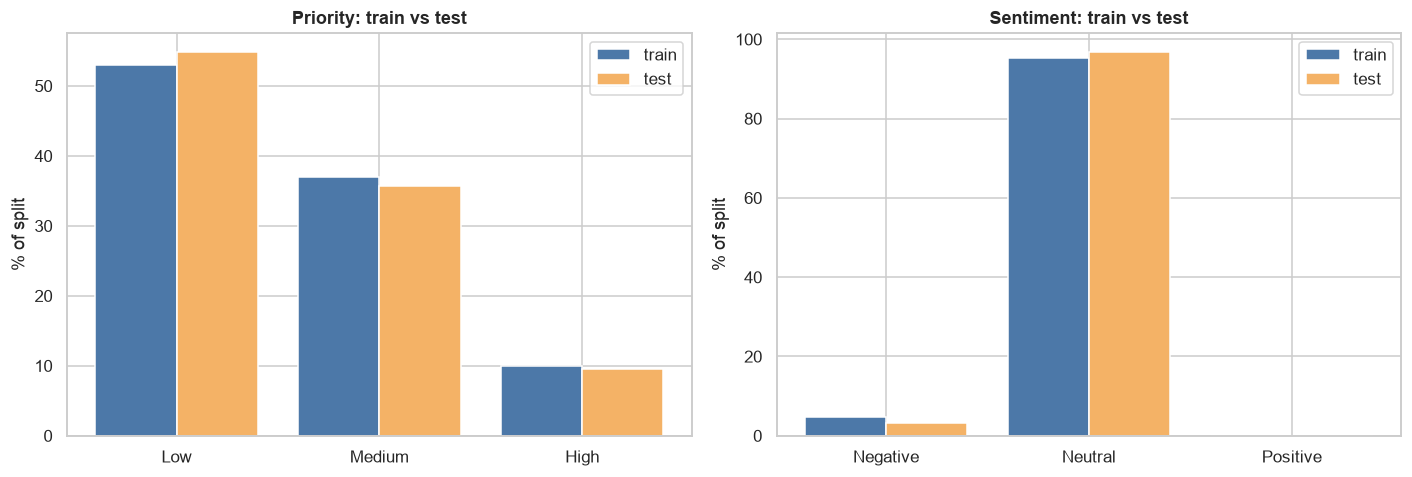

Largest per-category train/test gap: 0.949 pp


,train_%,test_%,gap_pp
category,,,
contactless_not_working,0.350,1.299,0.949
virtual_card_not_working,0.410,1.299,0.889
card_acceptance,0.590,1.299,0.709
card_swallowed,0.610,1.299,0.689
card_payment_fee_charged,1.869,1.299,0.571
direct_debit_payment_not_recognised,1.819,1.299,0.521
balance_not_updated_after_cheque_or_cash_deposit,1.809,1.299,0.511
wrong_amount_of_cash_received,1.799,1.299,0.501
lost_or_stolen_card,0.820,1.299,0.479


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, col, order, colors in [
    (axes[0], "priority", PRIORITY_ORDER, PRIORITY_COLORS),
    (axes[1], "sentiment", SENTIMENT_ORDER, SENTIMENT_COLORS),
]:
    comp = pd.DataFrame(
        {
            "train": df[col].value_counts(normalize=True).reindex(order).fillna(0) * 100,
            "test": test_df[col].value_counts(normalize=True).reindex(order).fillna(0) * 100,
        }
    )
    x = np.arange(len(order))
    ax.bar(x - 0.2, comp["train"], 0.4, label="train", color="#4C78A8")
    ax.bar(x + 0.2, comp["test"], 0.4, label="test", color="#F4B266")
    ax.set_xticks(x)
    ax.set_xticklabels(order)
    ax.set_title(f"{col.capitalize()}: train vs test")
    ax.set_ylabel("% of split")
    ax.legend()

plt.show()

# Max per-category percentage-point gap — the sharpest test of split drift.
cat_comp = pd.DataFrame(
    {
        "train_%": df["category"].value_counts(normalize=True) * 100,
        "test_%": test_df["category"].value_counts(normalize=True) * 100,
    }
).fillna(0)
cat_comp["gap_pp"] = (cat_comp["train_%"] - cat_comp["test_%"]).abs().round(3)
print(f"Largest per-category train/test gap: {cat_comp['gap_pp'].max():.3f} pp")
cat_comp.sort_values("gap_pp", ascending=False).head(10).round(3)

## 11. Summary

Generated from the values computed above rather than typed by hand, so it
stays correct if the file is replaced.

In [30]:
print(f"""
DATASET PROFILE — {TRAIN_PATH.name}
{'=' * 62}

SIZE
  {len(df):,} labelled tickets, 3 label columns (category/sentiment/priority), English only
  Integrity: {df.isna().sum().sum()} nulls, {full_dupes} duplicate rows, {len(conflicts)} label conflicts

TEXT
  Median {df['n_words'].median():.0f} words / {df['n_chars'].median():.0f} chars; 95th pct {p95:.0f} words; max {df['n_words'].max()} words
  {text.str.strip().str.endswith('?').mean():.0%} are phrased as questions — short, conversational, one-intent
  Vocabulary {len(vocab):,} types over {total_tokens:,} tokens

CATEGORY  ({df['category'].nunique()} classes)
  Range {cat_counts.min()}–{cat_counts.max()} per class, {cat_counts.iloc[0] / cat_counts.iloc[-1]:.1f}x imbalance
  Normalised entropy {entropy / max_entropy:.3f} — frequencies are close to even
  Difficulty is the class COUNT and thin absolute support, not skew
  {len(thin)} classes under 50 samples; median {cat_counts.median():.0f} per class

SENTIMENT
  {' / '.join(f'{k} {v / len(df):.0%}' for k, v in sent_counts.items())}
  {present.max() / present.min():.0f}x imbalance (Negative vs Neutral) — Positive is absent under v5

PRIORITY
  {' / '.join(f'{k} {v / len(df):.0%}' for k, v in prio_counts.items())}
  {prio_counts.max() / prio_counts.min():.1f}x imbalance

LABEL RELATIONSHIPS
  {(prio_per_cat == 1).sum()}/{n_cats} categories have a single fixed priority
  Category alone predicts priority at {baseline_acc:.0%} (majority-rule ceiling)
  Priority-sentiment association (Cramér's V): {cramers_v:.3f}

SPLIT
  Train {len(df):,} / test {len(test_df):,} ({len(test_df) / (len(df) + len(test_df)):.0%} test)
  Text overlap: {len(overlap)}; max per-category gap {cat_comp['gap_pp'].max():.2f} pp
""")


DATASET PROFILE — train_labeled.csv

SIZE
  10,003 labelled tickets, 3 label columns (category/sentiment/priority), English only
  Integrity: 0 nulls, 2 duplicate rows, 0 label conflicts

TEXT
  Median 10 words / 47 chars; 95th pct 30 words; max 79 words
  60% are phrased as questions — short, conversational, one-intent
  Vocabulary 2,354 types over 119,825 tokens

CATEGORY  (77 classes)
  Range 35–187 per class, 5.3x imbalance
  Normalised entropy 0.992 — frequencies are close to even
  Difficulty is the class COUNT and thin absolute support, not skew
  2 classes under 50 samples; median 127 per class

SENTIMENT
  Negative 5% / Neutral 95% / Positive 0%
  21x imbalance (Negative vs Neutral) — Positive is absent under v5

PRIORITY
  Low 53% / Medium 37% / High 10%
  5.3x imbalance

LABEL RELATIONSHIPS
  22/77 categories have a single fixed priority
  Category alone predicts priority at 93% (majority-rule ceiling)
  Priority-sentiment association (Cramér's V): 0.310

SPLIT
  Train 10,0

### What this means for modelling

**Category is the hard target — but not because of imbalance.** Frequencies
are close to even (normalised entropy 0.99, only 5.3x between the largest and
smallest class). The difficulty is the sheer number of classes (77) and the
thin absolute support behind each one: a median of ~127 examples to separate
77 fine-grained, semantically adjacent intents, several of which overlap
heavily (`card_arrival` vs `card_delivery_estimate`, the various
`balance_not_updated_after_*` classes). Report **macro-F1** and read the
per-class breakdown; expect confusion within these near-synonym clusters
rather than a head-vs-tail failure. The two classes under 50 samples are the
weakest points.

**Sentiment is effectively binary under v5, not 3-class.** The v5 labeling
prompt assigns `Positive` to **zero** tickets in this split (Negative 4.6% /
Neutral 95.4%) — confirmed by an independent 500-row human-annotated gold set,
which also has 0 `Positive` tickets. This isn't a labeling bug: customers
writing into a support channel essentially never do so to express positive
sentiment. Treat this as binary Negative-vs-Neutral classification in
practice; a `Positive` class in the model's output head is now vestigial for
this dataset. Negative is still the operationally important class since it
drives escalation — use class weights or resampling, and evaluate on
per-class recall for Negative rather than on the aggregate.

**Priority is correlated with category, but less deterministically than
before v5's recalibration.** Only 22 of 77 categories now carry a single fixed
priority (down from a pre-v5 41/77), and predicting each category's most
common priority reproduces the label 93% of the time (down from a pre-v5 97%).
The four categories v5 specifically recalibrated — `pin_blocked`,
`passcode_forgotten`, `card_swallowed`, `unable_to_verify_identity` — went
from a single hardcoded "always High" heuristic label to a real, more mixed
priority distribution, which is exactly what added the extra within-category
variance. Priority-sentiment association also strengthened (Cramér's V 0.31,
up from 0.22 pre-v5). Two implications: (1) 93% is the bar a dedicated
priority model must beat; (2) there is now more genuine signal in the text for
a priority classifier to learn than there was under the old heuristic labels.

**Text is short and single-intent.** The 95th percentile sits well inside a
64-token budget, so a max sequence length of 64–128 covers effectively the
whole corpus; anything longer just wastes compute on padding.

**The split is clean and now fully v5-consistent.** No exact text overlap,
category proportions match closely (max per-category gap under 1pp), and
`test_labeled.csv` has now been through the same v5 labeling pass as
`train_labeled.csv` (previously it only had it for `category`, and carried
pre-v5 heuristic sentiment/priority labels — that gap is now closed). Test
scores for sentiment and priority are trustworthy against this split without
needing to account for a pipeline lag.

**This is the English reference profile.** The Sinhala and Singlish splits
are derived from the same v5 label space and are row-aligned to this file (0
label mismatches verified) — rerun this notebook against them, and compare
vocabulary size and length statistics here against those, since translation
and transliteration change token counts substantially and affect the
sequence-length choice per language.